Libraries imported successfully.
 Model loaded successfully from:
  ./Results/Trained_Models/RS42_consensus_n7_fast_aggr_False_DecisionTree_model.pkl

 Training data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_train_data.parquet (shape: (53, 8))
 Test data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_test_data.parquet (shape: (10, 8))
 Predictions made for both training and test sets.
  - Training predictions shape: (53,)
  - Test predictions shape: (10,)
╔═════════════════╦═════════════╦═════════════╗
║   Metric        ║  Train Set  ║   Test Set  ║
╠═════════════════╬═════════════╬═════════════╣
║ R² (R-squared)  ║   0.7116    ║   0.6522    ║
║ RMSE            ║   16.86      ║   18.35      ║
╚═════════════════╩═════════════╩═════════════╝


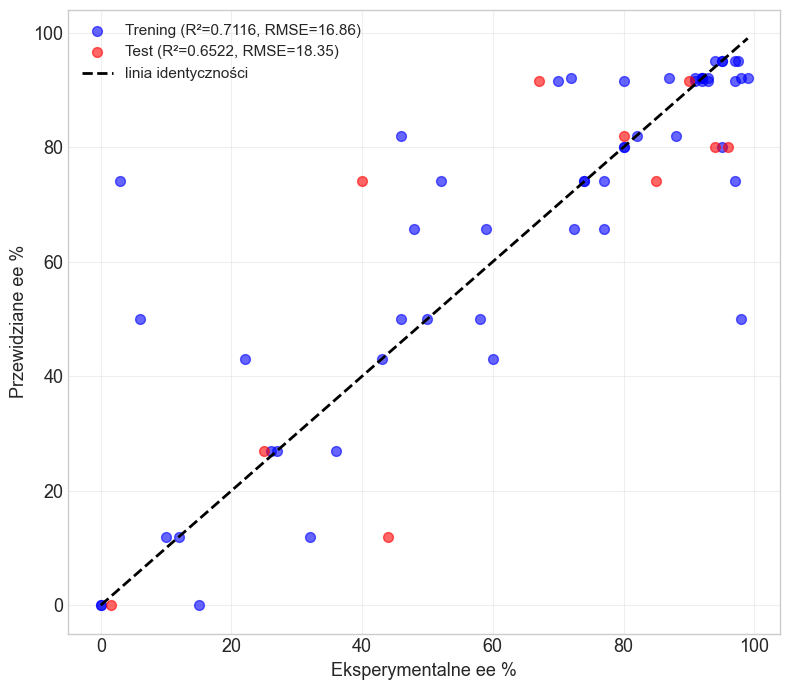

 Combined plot generated successfully


In [32]:
# # QSPR Model Verification and Visualization
# 
# This notebook loads a previously trained model and its corresponding training/test data to:
# 1.  Verify the model's performance by recalculating key metrics.
# 2.  Generate a publication-quality scatter plot of observed vs. predicted values.
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Libraries imported successfully.")

# ===================================================================
# CONFIGURATION: Specify file paths
# ===================================================================
model_path = './Results/Trained_Models/RS42_consensus_n7_fast_aggr_False_DecisionTree_model.pkl'
train_data_path = './Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_train_data.parquet'
test_data_path = './Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_test_data.parquet'

# Load the model
model = joblib.load(model_path)
print(f" Model loaded successfully from:\n  {model_path}\n")

# Load the datasets
train_df = pd.read_parquet(train_data_path)
test_df = pd.read_parquet(test_data_path)
print(f" Training data loaded successfully from:\n  {train_data_path} (shape: {train_df.shape})")
print(f" Test data loaded successfully from:\n  {test_data_path} (shape: {test_df.shape})")
# ## Prepare Data and Make Predictions

# ===================================================================
# DATA PREPARATION AND PREDICTION
# ===================================================================
# Separate features (X) and target (y)
TARGET_COLUMN = 'ee'

X_train = train_df.drop(columns=[TARGET_COLUMN])
X_train = X_train[list(train_df.iloc[:, :-1].columns)]
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
X_test = X_test[list(train_df.iloc[:, :-1].columns)]
y_test = test_df[TARGET_COLUMN]

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# ===================================================================
# PERFORMANCE VERIFICATION
# ===================================================================
# Calculate metrics for the training set
train_r2 = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Calculate metrics for the test set
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("╔═════════════════╦═════════════╦═════════════╗")
print("║   Metric        ║  Train Set  ║   Test Set  ║")
print("╠═════════════════╬═════════════╬═════════════╣")
print(f"║ R² (R-squared)  ║   {train_r2:.4f}    ║   {test_r2:.4f}    ║")
print(f"║ RMSE            ║   {train_rmse:.2f}      ║   {test_rmse:.2f}      ║")
print("╚═════════════════╩═════════════╩═════════════╝")

# ===================================================================
# PLOT OBSERVED VS. PREDICTED (COMBINED) AND SAVE FIGURE
# ===================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Plot both training and test data on the same axes
ax.scatter(y_train, y_pred_train, c='blue', alpha=0.6, s=50, label=f'Trening (R²={train_r2:.4f}, RMSE={train_rmse:.2f})')
ax.scatter(y_test, y_pred_test, c='red', alpha=0.6, s=50, label=f'Test (R²={test_r2:.4f}, RMSE={test_rmse:.2f})')

# Identity line
all_y = np.concatenate([y_train, y_test])
all_pred = np.concatenate([y_pred_train, y_pred_test])
min_val = min(all_y.min(), all_pred.min())
max_val = max(all_y.max(), all_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='linia identyczności')

# Labels and title
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_xlabel('Eksperymentalne ee %', fontsize=13)
ax.set_ylabel('Przewidziane ee %', fontsize=13)
#ax.set_title('Model Performance: Training and Test Sets', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('model_performance_combined.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

print(" Combined plot generated successfully")

In [2]:
model[2]

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [3]:
## Validation set

import sys
import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path
from datetime import datetime

# Add module path for imports
module_path = Path('.').parent / 'module'  # Adjust if needed
if module_path.exists():
    sys.path.insert(0, str(module_path))
    print(f" Module path added: {module_path}")
else:
    print(f" Module path not found: {module_path}")
    print(f"  Current directory: {Path('.').resolve()}")
    print(f"  Please ensure calculate_descriptors.py is in a 'module' subdirectory")

warnings.filterwarnings('ignore')

# Import from your QSPR module
try:
    from calculate_descriptors import prepare_data
    print(" Successfully imported from calculate_descriptors.py")
except ImportError as e:
    print(f" Error importing from models_creation.py: {e}")
    raise

print("\n All imports successful")

 Module path added: module

╔════════════════════════════════════════════════════════════════════════════╗
║                                                                            ║
║                calculate_descriptors.py MODULE READY                       ║
║                                                                            ║
║         Import this module in your QSPR analysis scripts                   ║
║         Location: module/calculate_descriptors.py                          ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
    
 Successfully imported from calculate_descriptors.py

 All imports successful


In [4]:
CONFIG = {
    # Data file
    'data': './Data/Exp_verification_III_modyfikacja_10struktur.xlsx',
    'target_col': 'ee',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [5]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/Exp_verification_III_modyfikacja_10struktur.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (10, 4110)
Returning: full descriptor set

 Data loaded and ALL descriptors 

In [6]:
X_train.columns

Index(['IC1', 'GATS6are', 'ATSC1c', 'CIC1', 'GATS4d', 'PEOE_VSA6', 'SMR_VSA6'], dtype='object')

In [7]:
data[list(X_train.columns)]

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000


In [8]:
y_pred_val = model.predict(data[list(X_train.columns)])

In [9]:
y_pred_val

array([65.75, 65.75, 50.  , 65.75, 92.  , 80.  , 65.75, 91.5 , 65.75,
       74.  ])

In [10]:
y_pred_val[0]

np.float64(65.75)

In [11]:
data['ee']

0    66.0
1    73.0
2    27.0
3    56.0
4    92.0
5    79.5
6    47.0
7    88.0
8    65.0
9    43.5
Name: ee, dtype: float64

In [12]:
# Calculate metrics for the validation set
val_r2 = r2_score(data['ee'], y_pred_val)
val_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_val))

In [13]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Validation Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {val_r2:.4f}                  ║")
print(f"║ RMSE            ║   {val_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Validation Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [14]:


for x in range(len(y_pred_val)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_val[x]))

Observed ee: 66.0   Predicted ee: 65.75
Observed ee: 73.0   Predicted ee: 65.75
Observed ee: 27.0   Predicted ee: 50.0
Observed ee: 56.0   Predicted ee: 65.75
Observed ee: 92.0   Predicted ee: 92.0
Observed ee: 79.5   Predicted ee: 80.0
Observed ee: 47.0   Predicted ee: 65.75
Observed ee: 88.0   Predicted ee: 91.5
Observed ee: 65.0   Predicted ee: 65.75
Observed ee: 43.5   Predicted ee: 74.0


In [15]:
validation_data = './Data/Exp_verification_III_modyfikacja_10struktur.xlsx'


# Load the datasets
val_df = pd.read_excel(validation_data)
val_df.head(1)

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0


Observed ee: 66.0   Predicted ee: 65.75


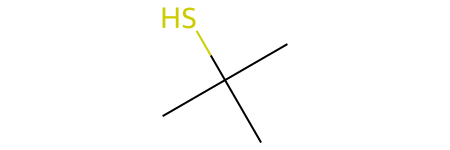

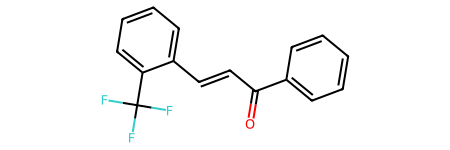

Observed ee: 73.0   Predicted ee: 65.75


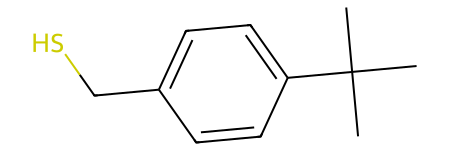

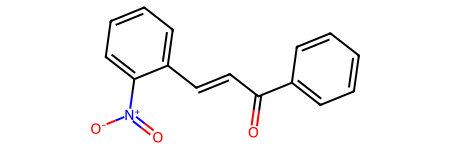

Observed ee: 27.0   Predicted ee: 50.0


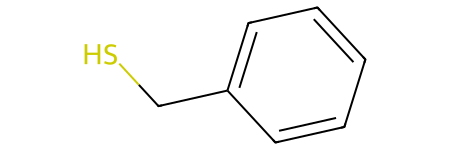

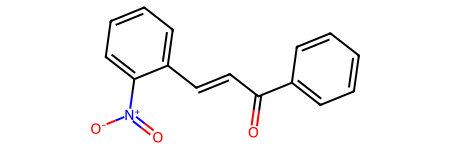

Observed ee: 56.0   Predicted ee: 65.75


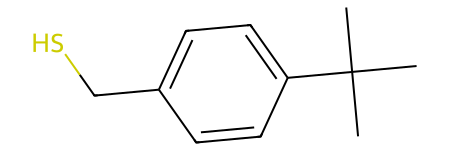

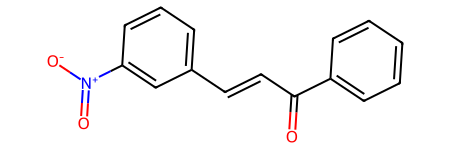

Observed ee: 92.0   Predicted ee: 92.0


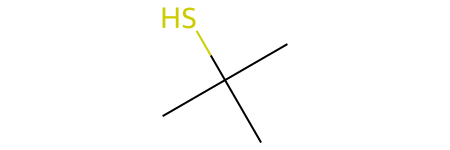

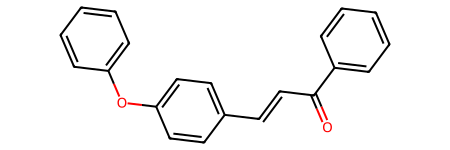

Observed ee: 79.5   Predicted ee: 80.0


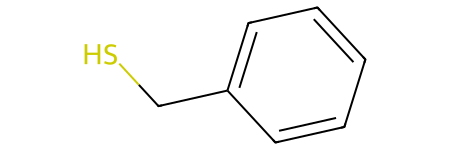

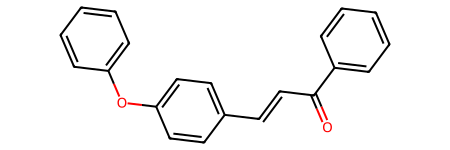

Observed ee: 47.0   Predicted ee: 65.75


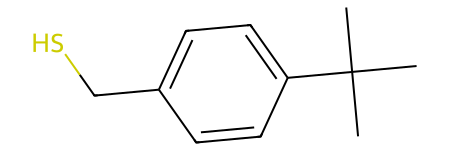

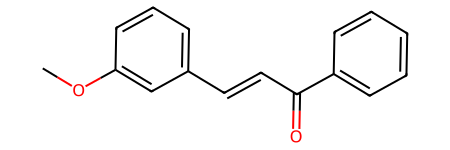

Observed ee: 88.0   Predicted ee: 91.5


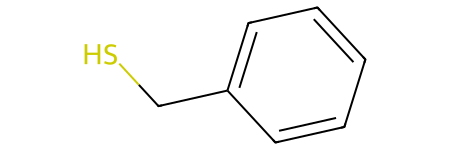

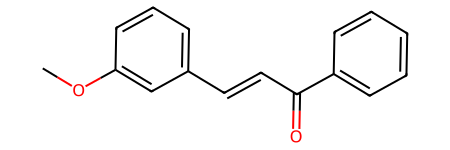

Observed ee: 65.0   Predicted ee: 65.75


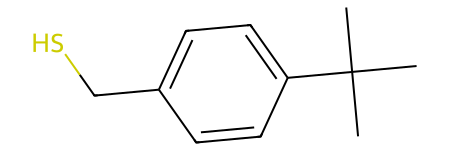

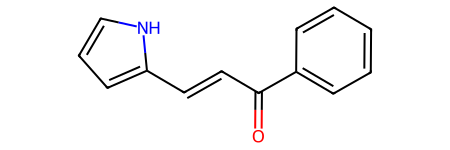

Observed ee: 43.5   Predicted ee: 74.0


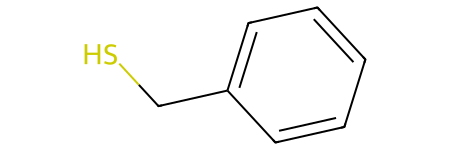

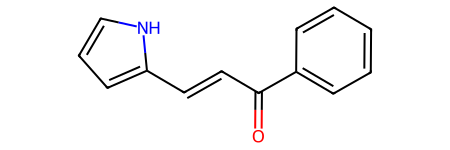

In [16]:

from rdkit import Chem
from IPython.display import display

for x in range(len(y_pred_val)):
    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " + str(y_pred_val[x]))
    mol = Chem.MolFromSmiles(val_df['SMILES_tiol'][x])
    display(mol)
    mol = Chem.MolFromSmiles(val_df['SMILES_chalkon'][x])
    display(mol)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings('ignore')


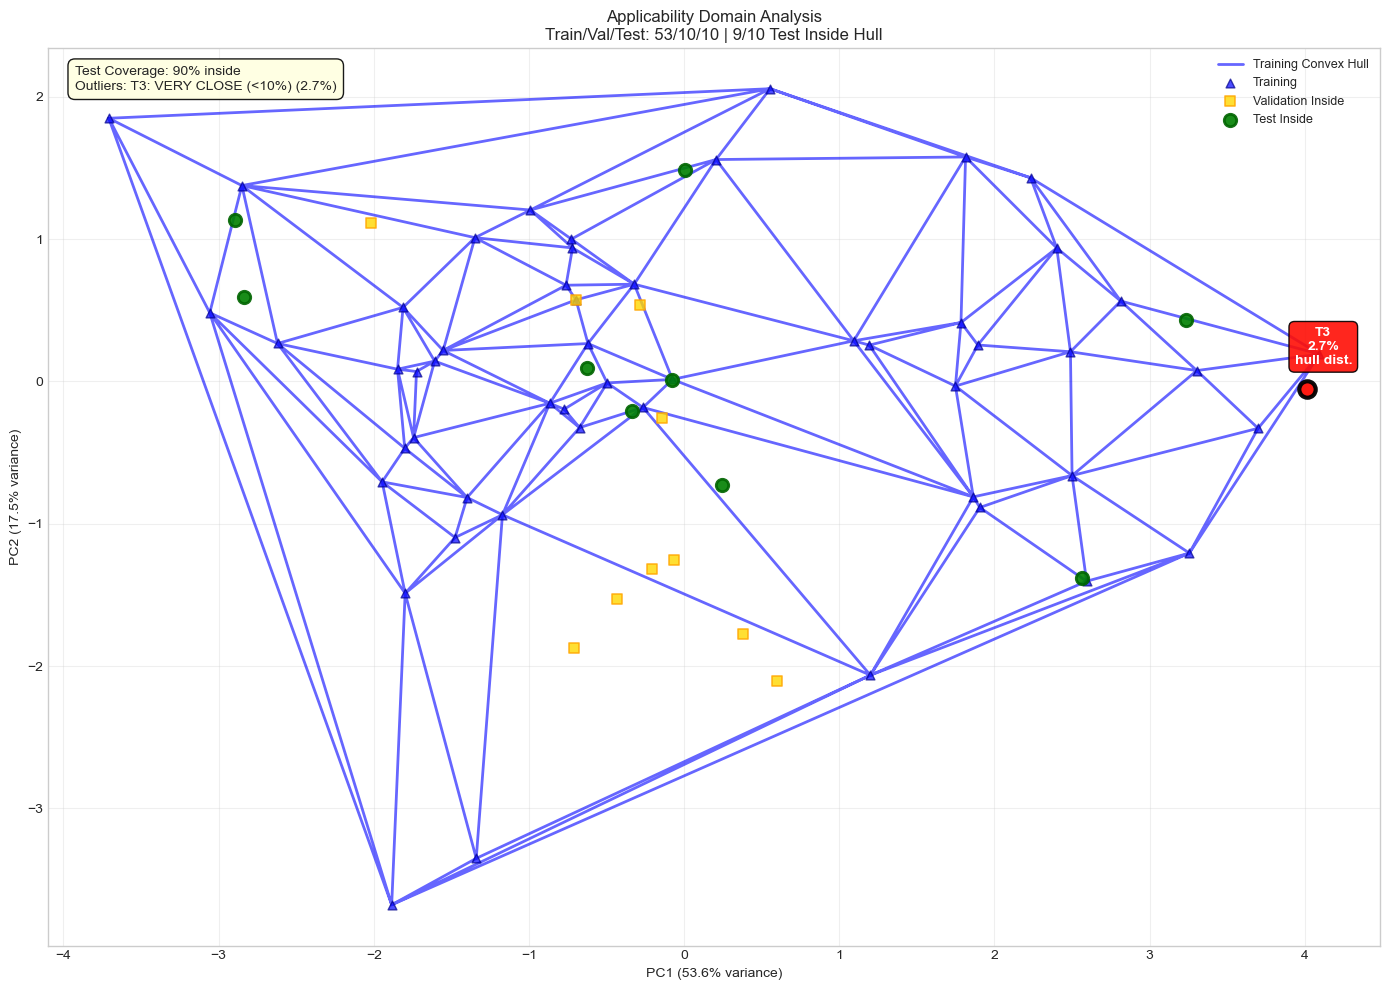

Outlier Analysis:
  T3: VERY CLOSE (<10%) (2.7%)

Summary: 9/10 test points inside hull (90.0%)
Detailed outlier info: {'T3': {'dist_to_hull': np.float64(0.05365692148388656), 'dist_to_edge': np.float64(0.05365692148388656), 'dist_to_vertex': np.float64(0.2562645011974097), 'hull_radius': np.float64(1.999234642114432), 'relative_dist_%': np.float64(2.6838731359285517)}}


In [18]:
def analyze_applicability_detailed(X_train, X_val, X_test):
    """Single plot version"""
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    from scipy.spatial import Delaunay
    tri = Delaunay(X_train_pca)
    
    # Masks
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0

    # Distance calculation
    def point_to_hull_distance(point, tri, X_train_pca):
        """Stable distance to convex hull"""
        min_dist = np.inf
        
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        center = np.mean(X_train_pca, axis=0)
        hull_radius = np.mean(np.linalg.norm(X_train_pca - center, axis=1))
        
        total_min_dist = min(dist_vertices, min_edge_dist)
        
        return {
            'dist_to_hull': total_min_dist,
            'dist_to_edge': min_edge_dist,
            'dist_to_vertex': dist_vertices,
            'hull_radius': hull_radius,
            'relative_dist_%': (total_min_dist / hull_radius) * 100
        }

    # Analyze outliers
    outlier_info = {}
    outlier_descriptions = []
    for i, is_inside in enumerate(test_inside_mask):
        if not is_inside:
            info = point_to_hull_distance(X_test_pca[i], tri, X_train_pca)
            outlier_info[f'T{i}'] = info
            
            # English classification
            rel_dist = info['relative_dist_%']
            if rel_dist < 10:
                desc = "VERY CLOSE (<10%)"
            elif rel_dist < 25:
                desc = "CLOSE (10-25%)"
            else:
                desc = "FAR (>25%)"
            
            outlier_descriptions.append(f"T{i}: {desc} ({rel_dist:.1f}%)")

    # SINGLE PLOT - FULL FEATURES
    plt.figure(figsize=(14, 10))
    
    # Convex hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                'b-', alpha=0.6, linewidth=2, label='Training Convex Hull')

    # Training points
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=40, 
                alpha=0.7, marker='^', edgecolors='darkblue', label='Training')

    # Validation points
    plt.scatter(X_val_pca[val_inside_mask, 0], X_val_pca[val_inside_mask, 1], 
                c='gold', s=60, marker='s', alpha=0.8, 
                edgecolors='orange', label='Validation Inside', linewidth=1.2)
    if np.any(~val_inside_mask):
        plt.scatter(X_val_pca[~val_inside_mask, 0], X_val_pca[~val_inside_mask, 1], 
                    c='orange', s=60, marker='s', alpha=0.8, 
                    edgecolors='darkorange', label='Validation Outside', linewidth=1.2)

    # Test inside
    plt.scatter(X_test_pca[test_inside_mask, 0], X_test_pca[test_inside_mask, 1], 
                c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                label='Test Inside', linewidth=2)

    # Test outside WITH DISTANCES
    test_outside_idx = np.where(~test_inside_mask)[0]
    for i, idx in enumerate(test_outside_idx):
        dist_pct = outlier_info[f'T{idx}']['relative_dist_%']
        color_intensity = min(dist_pct / 30, 1)
        color = (1, color_intensity*0.6, color_intensity*0.2)  # Red gradient
        
        plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], 
                   c=color, s=140, alpha=0.95, edgecolors='black', linewidth=3)
        
        # Distance annotation
        plt.annotate(f'T{idx}\n{dist_pct:.1f}%\nhull dist.', 
                    (X_test_pca[idx, 0], X_test_pca[idx, 1]), 
                    xytext=(12, 18), textcoords='offset points', fontsize=10,
                    color='white', fontweight='bold', ha='center',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.9))

    # Title and labels
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title(f'Applicability Domain Analysis\n'
              f'Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)} | '
              f'{np.sum(test_inside_mask)}/{len(test_inside_mask)} Test Inside Hull')
    
    # Legend with outlier summary
    legend_text = f"Test Coverage: {100*np.sum(test_inside_mask)/len(test_inside_mask):.0f}% inside"
    if outlier_descriptions:
        legend_text += f"\nOutliers: {', '.join(outlier_descriptions)}"
    
    plt.text(0.02, 0.98, legend_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.9))
    
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save publication-ready
    plt.savefig('applicability_domain_single_plot.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.png', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.svg', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Outlier Analysis:")
    for desc in outlier_descriptions:
        print(f"  {desc}")
    print(f"\nSummary: {np.sum(test_inside_mask)}/{len(test_inside_mask)} test points inside hull "
          f"({100*np.sum(test_inside_mask)/len(test_inside_mask):.1f}%)")
    
    return {
        'test_inside_mask': test_inside_mask,
        'val_inside_mask': val_inside_mask,
        'outlier_info': outlier_info,
        'outlier_descriptions': outlier_descriptions
    }

# USAGE:
result = analyze_applicability_detailed(X_train, data[list(X_train.columns)], X_test)
print("Detailed outlier info:", result['outlier_info'])


In [19]:
def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    
    Heuristic Logic:
    - Inside Hull -> In Domain
    - Outside Hull:
        - rel_dist = dist_to_hull / dist_to_centroid
        - if rel_dist < threshold -> In Domain (Extended)
        - if rel_dist >= threshold -> Out of Domain
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay)
    tri = Delaunay(X_train_pca)
    
    # Basic containment check
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0
    
    # Geometric center of training data (Centroid)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        # Avoid division by zero
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return {
            'r_d_hull': r_d_hull,
            'r_geometrical_center': r_geometrical_center,
            'rel_distance': rel_distance
        }

    # 4. Analyze Test Points with Heuristic
    test_status = [] # 'inside', 'extended', 'out'
    outlier_details = {}
    
    for i in range(len(X_test_pca)):
        if test_inside_mask[i]:
            test_status.append('inside')
        else:
            # Calculate heuristic metrics
            info = get_hull_distance_info(X_test_pca[i], tri, X_train_pca, centroid_train)
            rel_dist = info['rel_distance']
            
            outlier_details[f'T{i}'] = info
            
            if rel_dist < heuristic_threshold:
                test_status.append('extended') # Outside hull but acceptable
            else:
                test_status.append('out') # Outside hull and unacceptable

    test_status = np.array(test_status)

    # 5. PLOTTING
    plt.figure(figsize=(12, 9))
    
    # A. Draw Hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                color='gray', alpha=0.4, linewidth=1, label='Training Convex Hull')

    # B. Plot Points
    # Training
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=30, 
                alpha=0.5, marker='o', label='Training Data')

    # Validation (Optional visualization)
    plt.scatter(X_val_pca[:, 0], X_val_pca[:, 1], c='orange', s=30, marker='s', alpha=0.6, label='Validation')

    # Test: Inside Hull (Safe)
    mask_in = test_status == 'inside'
    if np.any(mask_in):
        plt.scatter(X_test_pca[mask_in, 0], X_test_pca[mask_in, 1], 
                   c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                   label='Test: Inside Hull (Safe)')

    # Test: Extended Domain (Heuristic Acceptable)
    mask_ext = test_status == 'extended'
    if np.any(mask_ext):
        plt.scatter(X_test_pca[mask_ext, 0], X_test_pca[mask_ext, 1], 
                   c='yellowgreen', s=100, marker='D', alpha=0.9, edgecolors='black', 
                   label=f'Test: Extended Domain (rel_dist < {heuristic_threshold})')
        
        # Annotate extended points
        for idx in np.where(mask_ext)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8)

    # Test: Out of Domain
    mask_out = test_status == 'out'
    if np.any(mask_out):
        plt.scatter(X_test_pca[mask_out, 0], X_test_pca[mask_out, 1], 
                   c='red', s=120, marker='X', alpha=0.9, edgecolors='black', 
                   label=f'Test: Out of Domain (rel_dist >= {heuristic_threshold})')

        # Annotate outliers
        for idx in np.where(mask_out)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', 
                         color='red', fontweight='bold', fontsize=9)

    # Plot Centroid
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, linewidth=2, label='Train Centroid')

    # Formatting
    plt.title(f'Applicability Domain Analysis (Heuristic Threshold = {heuristic_threshold})\n'
              f'Total Test: {len(X_test)} | Safe: {np.sum(mask_in)} | '
              f'Extended: {np.sum(mask_ext)} | Outliers: {np.sum(mask_out)}')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    plt.legend(loc='upper right', frameon=True, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save
    plt.savefig('AD_heuristic_plot.png', dpi=300)
    plt.savefig('AD_heuristic_plot.svg', dpi=300)
    plt.show()

    # Text Summary
    print("-" * 50)
    print("HEURISTIC SUMMARY")
    print("-" * 50)
    print(f"Threshold (rel_distance): {heuristic_threshold}")
    print(f"Inside Hull (Safe):       {np.sum(mask_in)}")
    print(f"Extended Domain (Safe):   {np.sum(mask_ext)}")
    print(f"Out of Domain (Unsafe):   {np.sum(mask_out)}")
    print("-" * 50)
    
    if len(outlier_details) > 0:
        print("\nDetails for points outside hull:")
        print(f"{'ID':<5} | {'r_hull':<10} | {'r_center':<10} | {'rel_dist':<10} | {'Status'}")
        for idx_str, info in outlier_details.items():
            status = "EXTENDED" if info['rel_distance'] < heuristic_threshold else "OUT"
            print(f"{idx_str:<5} | {info['r_d_hull']:.4f}     | {info['r_geometrical_center']:.4f}     | {info['rel_distance']:.4f}     | {status}")

    return {
        'test_status': test_status,
        'outlier_details': outlier_details,
        'mask_in': mask_in,
        'mask_extended': mask_ext,
        'mask_out': mask_out
    }

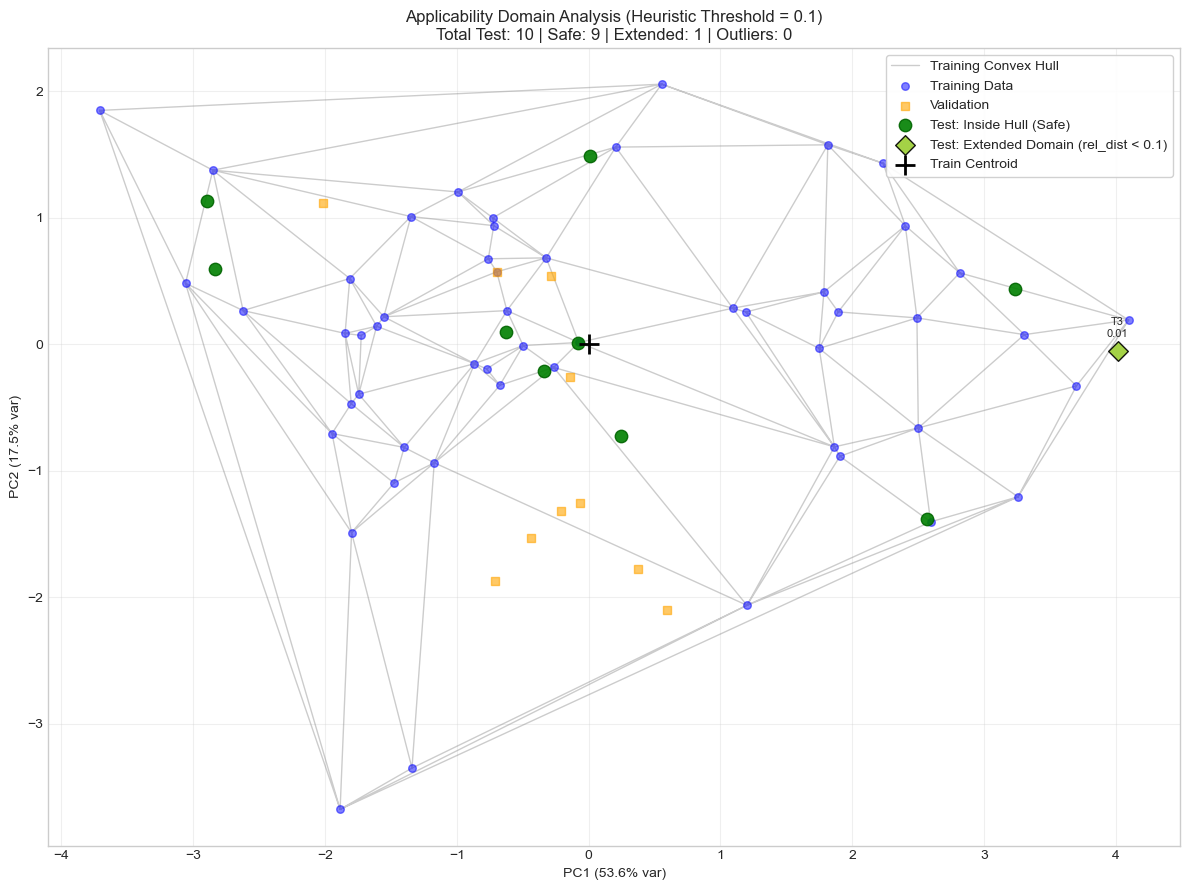

--------------------------------------------------
HEURISTIC SUMMARY
--------------------------------------------------
Threshold (rel_distance): 0.1
Inside Hull (Safe):       9
Extended Domain (Safe):   1
Out of Domain (Unsafe):   0
--------------------------------------------------

Details for points outside hull:
ID    | r_hull     | r_center   | rel_dist   | Status
T3    | 0.0537     | 4.0127     | 0.0134     | EXTENDED


In [20]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [21]:
CONFIG = {
    # Data file
    'data': './Data/Exp_verification_III_modyfikacja_10struktur.xlsx',
    'target_col': 'ee',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [22]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/Exp_verification_III_modyfikacja_10struktur.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (10, 4110)
Returning: full descriptor set

 Data loaded and ALL descriptors 

In [23]:
data[list(X_train.columns)]

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000


In [24]:
y_pred_exp = model.predict(data[list(X_train.columns)])

In [25]:
# Calculate metrics for the validation set
exp_r2 = r2_score(data['ee'], y_pred_exp)
exp_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_exp))

In [26]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Validation Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Validation Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [27]:


for x in range(len(y_pred_exp)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_exp[x]))

Observed ee: 66.0   Predicted ee: 65.75
Observed ee: 73.0   Predicted ee: 65.75
Observed ee: 27.0   Predicted ee: 50.0
Observed ee: 56.0   Predicted ee: 65.75
Observed ee: 92.0   Predicted ee: 92.0
Observed ee: 79.5   Predicted ee: 80.0
Observed ee: 47.0   Predicted ee: 65.75
Observed ee: 88.0   Predicted ee: 91.5
Observed ee: 65.0   Predicted ee: 65.75
Observed ee: 43.5   Predicted ee: 74.0


In [28]:
exp_data = './Data/Exp_verification_III_modyfikacja_10struktur.xlsx'


# Load the datasets
exp_df = pd.read_excel(exp_data)
exp_df.head(1)

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    Returns dictionaries containing processed DataFrames for Experimental (Val) and Test sets,
    printing indices of molecules outside the safe domain.
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay) on Training Data
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return rel_distance

    # 4. Universal Function to Process Any Dataset
    def process_dataset(X_data, X_pca_data, dataset_name="Data"):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))
            
        is_inside = tri.find_simplex(X_pca_data) >= 0
        
        status_list = []
        rel_dist_list = []
        
        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append('Inside Hull')
                rel_dist_list.append(0.0) 
            else:
                rel_dist = get_hull_distance_info(X_pca_data[i], tri, X_train_pca, centroid_train)
                rel_dist_list.append(rel_dist)
                
                if rel_dist < heuristic_threshold:
                    status_list.append('Extended Domain')
                else:
                    status_list.append('Out of Domain')
        
        df_out['AD_Status'] = status_list
        df_out['Rel_Distance'] = rel_dist_list
        # Dodajemy kolumnę pomocniczą z indeksem do łatwego dostępu
        df_out['Original_Index'] = indices
        
        return df_out, np.array(status_list)

    # 5. Apply Logic
    print("Processing Experimental Data...")
    X_val_df, val_statuses = process_dataset(X_val, X_val_pca, "Experimental")
    
    print("Processing Test Data...")
    X_test_df, test_statuses = process_dataset(X_test, X_test_pca, "Test")

    # 6. PLOTTING
    plt.figure(figsize=(12, 9))
    
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, color='gray', alpha=0.4)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', alpha=0.3, label='Training Data')
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, label='Centroid')

    style_map = {
        'Inside Hull':     {'c': 'green', 'm': 'o', 'alpha': 0.6},
        'Extended Domain': {'c': 'orange', 'm': 'D', 'alpha': 0.8},
        'Out of Domain':   {'c': 'red',   'm': 'X', 'alpha': 0.9}
    }

    # Helper function to plot and annotate
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df['AD_Status'] == status
            if mask.any():
                plt.scatter(pca_data[mask, 0], pca_data[mask, 1], 
                            c=style_map[status]['c'], marker=marker_style, s=60, edgecolors='black',
                            label=f'{label_prefix}: {status}')
                
                # Annotation for non-Inside points
                if status in ['Out of Domain', 'Extended Domain']:
                    idxs = np.where(mask)[0]
                    for idx in idxs:
                        dist = df.iloc[idx]['Rel_Distance']
                        mol_idx = df.iloc[idx]['Original_Index']
                        
                        #"Index: Distance annotation format"
                        label_text = f"#{mol_idx}\n{dist:.2f}"
                        
                        plt.annotate(label_text, 
                                     (pca_data[idx, 0], pca_data[idx, 1]),
                                     xytext=(5, 5), textcoords='offset points', 
                                     fontsize=8, fontweight='bold', color='black',
                                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

    plot_subset(X_val_df, X_val_pca, "Exp", 's')
    plot_subset(X_test_df, X_test_pca, "Test", 'P')

    plt.title(f'Applicability Domain (Threshold={heuristic_threshold})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('AD_heuristic_plot_EXP.svg', dpi=300)
    plt.show()

    # 7. Summary Print with Indices
    def print_outliers(df, name):
        print(f"\n--- Detailed Report: {name} Set ---")
        counts = df['AD_Status'].value_counts()
        print(counts)
        
        for status in ['Extended Domain', 'Out of Domain']:
            subset = df[df['AD_Status'] == status]
            if not subset.empty:
                print(f"\n[{status}] Molecules (Index -> Rel_Distance):")
                for _, row in subset.iterrows():
                    print(f"  - Index {row['Original_Index']}: {row['Rel_Distance']:.4f}")
            else:
                print(f"\n[{status}]: None")

    print_outliers(X_val_df, "Experimental")
    print_outliers(X_test_df, "Test")

    return {
        'exp_results_df': X_val_df,
        'test_results_df': X_test_df
    }


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analizuje domenę stosowalności z użyciem otoczki wypukłej i heurystyki odległości.
    Zwraca słowniki zawierające przetworzone DataFrame dla zbioru eksperymentalnego
    i testowego oraz wypisuje indeksy cząsteczek znajdujących się poza bezpiecznym obszarem.
    """
    
    # 1. Skalowanie i PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Otoczka wypukła (Delaunay) dla danych treningowych
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Funkcja pomocnicza: obliczanie odległości od otoczki
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Odległość od otoczki (podejście geometryczne)
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0, 1], [1, 2], [2, 0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Odległość od środka geometrycznego (centroidu)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Względny współczynnik odległości
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return rel_distance

    # 4. Uniwersalna funkcja do przetwarzania dowolnego zbioru danych
    def process_dataset(X_data, X_pca_data, dataset_name="Dane"):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))
            
        is_inside = tri.find_simplex(X_pca_data) >= 0
        
        status_list = []
        rel_dist_list = []
        
        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append('Wewnątrz otoczki')
                rel_dist_list.append(0.0)
            else:
                rel_dist = get_hull_distance_info(X_pca_data[i], tri, X_train_pca, centroid_train)
                rel_dist_list.append(rel_dist)
                
                if rel_dist < heuristic_threshold:
                    status_list.append('Rozszerzona domena')
                else:
                    status_list.append('Poza domeną')
        
        df_out['Status_AD'] = status_list
        df_out['Względna_odległość'] = rel_dist_list
        df_out['Indeks_oryginalny'] = indices
        
        return df_out, np.array(status_list)

    # 5. Zastosowanie logiki
    print("Przetwarzanie danych eksperymentalnych...")
    X_val_df, val_statuses = process_dataset(X_val, X_val_pca, "Eksperymentalny")
    
    print("Przetwarzanie danych testowych...")
    X_test_df, test_statuses = process_dataset(X_test, X_test_pca, "Testowy")

    # 6. Wykres
    plt.figure(figsize=(14, 10))
    
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, color='gray', alpha=0.4)
    plt.scatter(
        X_train_pca[:, 0], X_train_pca[:, 1],
        c='blue', alpha=0.3, s=80, label='Dane treningowe'
    )
    plt.scatter(
        centroid_train[0], centroid_train[1],
        c='black', marker='+', s=260, linewidths=2.5, label='Centroid'
    )

    style_map = {
        'Wewnątrz otoczki': {'c': 'green', 'm': 'o', 'alpha': 0.6},
        'Rozszerzona domena': {'c': 'orange', 'm': 'D', 'alpha': 0.8},
        'Poza domeną': {'c': 'red', 'm': 'X', 'alpha': 0.9}
    }

    # Funkcja pomocnicza do rysowania i adnotacji
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df['Status_AD'] == status
            if mask.any():
                plt.scatter(
                    pca_data[mask, 0], pca_data[mask, 1],
                    c=style_map[status]['c'],
                    marker=marker_style,
                    s=110,
                    edgecolors='black',
                    linewidths=1.2,
                    label=f'{label_prefix}: {status}'
                )
                
                if status in ['Poza domeną', 'Rozszerzona domena']:
                    idxs = np.where(mask)[0]
                    for idx in idxs:
                        dist = df.iloc[idx]['Względna_odległość']
                        mol_idx = df.iloc[idx]['Indeks_oryginalny']
                        
                        label_text = f"#{mol_idx}\n{dist:.2f}"
                        
                        plt.annotate(
                            label_text,
                            (pca_data[idx, 0], pca_data[idx, 1]),
                            xytext=(6, 6),
                            textcoords='offset points',
                            fontsize=16,
                            fontweight='bold',
                            color='black',
                            bbox=dict(
                                boxstyle="round,pad=0.25",
                                fc="white",
                                alpha=0.7
                            )
                        )

    plot_subset(X_val_df, X_val_pca, "Eksperymentalny", 's')
    plot_subset(X_test_df, X_test_pca, "Test", 'P')

    plt.title(f'Domena stosowalności (próg = {heuristic_threshold})', fontsize=22)
    plt.xlabel('PC1', fontsize=20)
    plt.ylabel('PC2', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=18,
        title='Legenda',
        title_fontsize=18
    )
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('applicability_domain_experimental_set.svg', dpi=300, bbox_inches='tight')
    plt.show()

    # 7. Raport tekstowy z indeksami
    def print_outliers(df, name):
        print(f"\n--- Raport szczegółowy: zbiór {name} ---")
        counts = df['Status_AD'].value_counts()
        print(counts)
        
        for status in ['Rozszerzona domena', 'Poza domeną']:
            subset = df[df['Status_AD'] == status]
            if not subset.empty:
                print(f"\n[{status}] Cząsteczki (indeks -> względna odległość):")
                for _, row in subset.iterrows():
                    print(f"  - Indeks {row['Indeks_oryginalny']}: {row['Względna_odległość']:.4f}")
            else:
                print(f"\n[{status}]: brak")

    print_outliers(X_val_df, "eksperymentalny")
    print_outliers(X_test_df, "testowy")

    return {
        'exp_results_df': X_val_df,
        'test_results_df': X_test_df
    }

Przetwarzanie danych eksperymentalnych...
Przetwarzanie danych testowych...


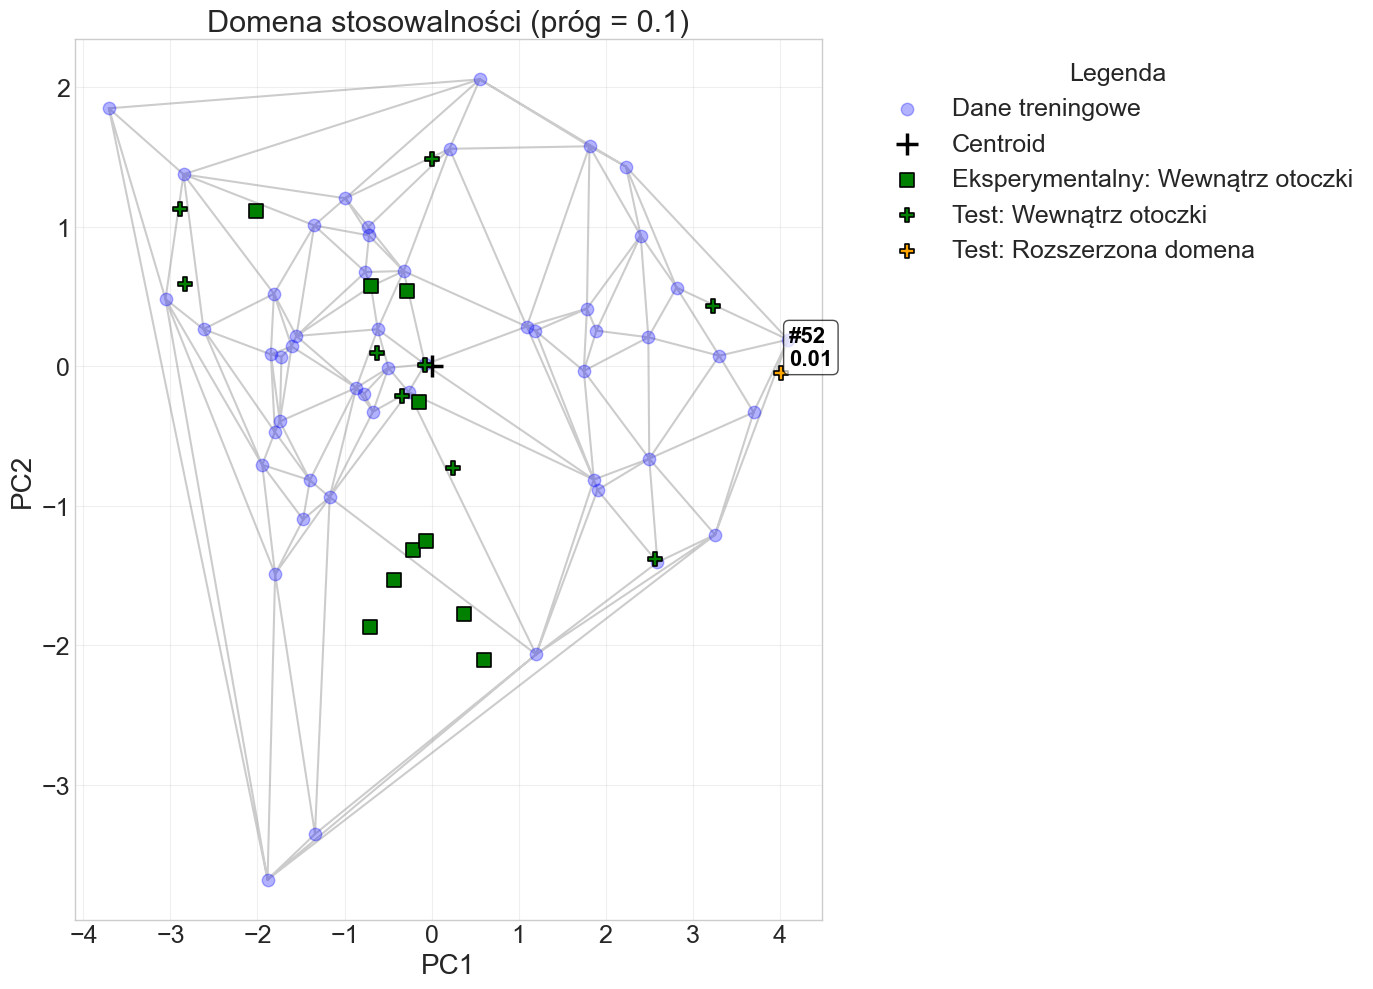


--- Raport szczegółowy: zbiór eksperymentalny ---
Status_AD
Wewnątrz otoczki    10
Name: count, dtype: int64

[Rozszerzona domena]: brak

[Poza domeną]: brak

--- Raport szczegółowy: zbiór testowy ---
Status_AD
Wewnątrz otoczki      9
Rozszerzona domena    1
Name: count, dtype: int64

[Rozszerzona domena] Cząsteczki (indeks -> względna odległość):
  - Indeks 52: 0.0134

[Poza domeną]: brak


In [31]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [31]:
result['exp_results_df']

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6,AD_Status,Rel_Distance,Original_Index
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000,Inside Hull,0.0,0
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000,Inside Hull,0.0,1
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000,Inside Hull,0.0,2
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000,Inside Hull,0.0,3
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000,Inside Hull,0.0,4
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000,Inside Hull,0.0,5
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798,Inside Hull,0.0,6
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798,Inside Hull,0.0,7
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000,Inside Hull,0.0,8
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000,Inside Hull,0.0,9


In [32]:
result['test_results_df']

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6,AD_Status,Rel_Distance,Original_Index
index,,,,,,,,,,
11,2.215431,1.700711,-0.084079,3.428425,1.009779,103.137893,0.000000,Inside Hull,0.000000,11
13,2.138687,1.302255,-0.081634,3.446276,1.042077,109.223566,0.000000,Inside Hull,0.000000,13
41,2.719416,1.389052,-0.201783,2.638136,0.824339,66.739691,0.000000,Inside Hull,0.000000,41
52,3.392153,1.191591,-0.545758,2.415202,1.005541,52.337799,19.972449,Extended Domain,0.013372,52
59,2.926247,0.176270,-0.069788,1.881108,0.631169,36.407855,0.000000,Inside Hull,0.000000,59
31,2.579349,1.702707,-0.089432,2.778203,0.975070,66.730038,0.000000,Inside Hull,0.000000,31
18,2.602357,0.800758,-0.274570,2.952232,0.847059,78.872425,0.000000,Inside Hull,0.000000,18
27,2.653997,1.188641,-0.089328,2.869565,0.875264,66.739691,0.000000,Inside Hull,0.000000,27
29,2.634762,0.933649,-0.172214,2.950201,1.121591,78.862772,7.109798,Inside Hull,0.000000,29


In [33]:
fig = exp_df
fig['predicted_ee'] = y_pred_exp
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00


In [34]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee,AD_Status
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75,Inside Hull
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75,Inside Hull
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00,Inside Hull
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75,Inside Hull
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00,Inside Hull


In [35]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

def draw_molgrid_with_results(df, 
                              smiles_col='SMILES_tiol',
                              smiles_col_2='SMILES_chalkon',
                              obs_col='ee', 
                              pred_col='predicted_ee',
                              hull_col='AD_Status',
                              n_per_row=4, 
                              max_mols=100, 
                              img_size=(400, 400)):

    combined_mols = []
    legends = []
    
    df_subset = df.head(max_mols)
    
    for idx, row in df_subset.iterrows():
        # Pobieramy oba SMILES
        smi1 = str(row[smiles_col])
        smi2 = str(row[smiles_col_2])
        
        # Łączymy je kropką przed konwersją na obiekt Mol
        combined_smi = f"{smi1}.{smi2}"
        mol = Chem.MolFromSmiles(combined_smi)
        
        if mol is not None:
            combined_mols.append(mol)
            
            obs = row[obs_col]
            pred = row[pred_col]
            hull = row[hull_col]
            error = abs(obs - pred)

            label = f"Obs: {obs:.1f} | Pred: {pred:.1f} | Err: {error:.1f}\nAD: {hull}"
            legends.append(label)
        else:
            print(f"Błąd konwersji SMILES na indeksie {idx}")

    dopts = rdMolDraw2D.MolDrawOptions()
    dopts.legendFontSize = 24  
    dopts.padding = 0.05
    dopts.bondLineWidth = 3
    
    # RDKit automatycznie rozmieści oba fragmenty obok siebie
    img = Draw.MolsToGridImage(
        combined_mols, 
        molsPerRow=n_per_row, 
        subImgSize=img_size, 
        legends=legends,
        useSVG=True,
        drawOptions=dopts
    )
    
    return img

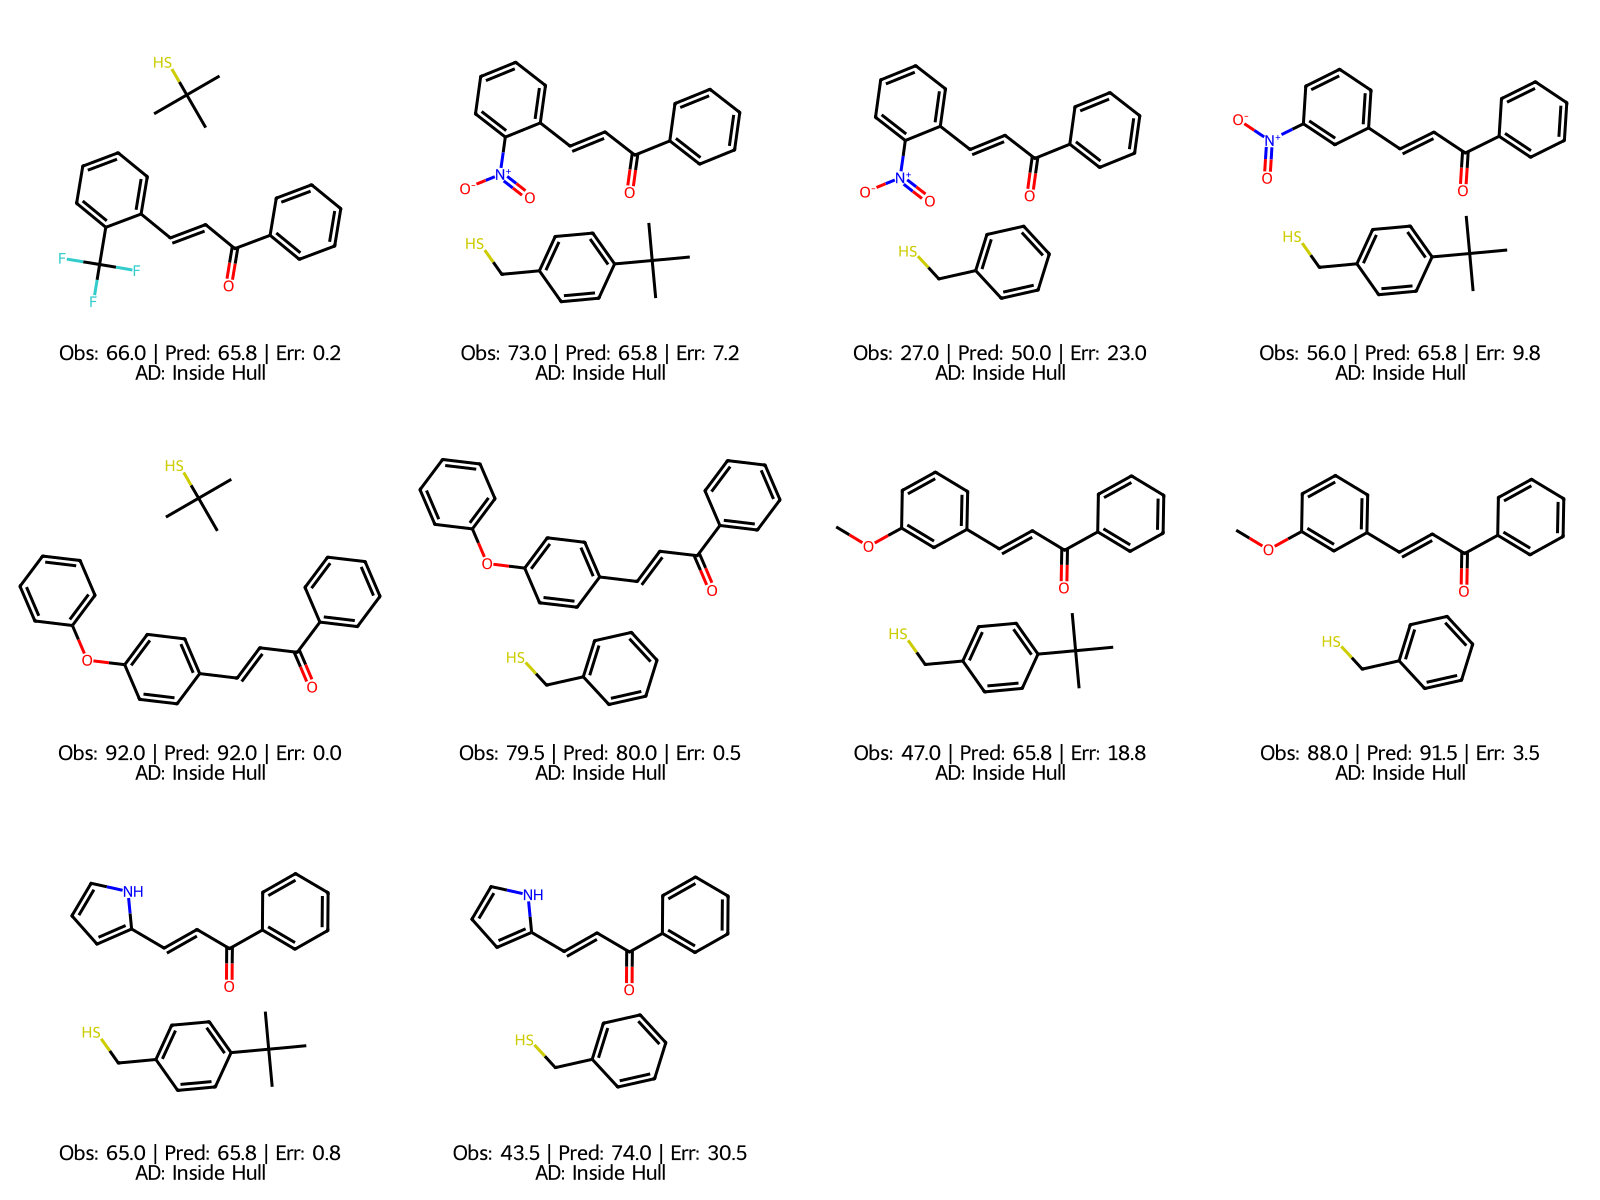

In [36]:
img = draw_molgrid_with_results(fig, max_mols=100)
display(img)

In [37]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee,AD_Status
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75,Inside Hull
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75,Inside Hull
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00,Inside Hull
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75,Inside Hull
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00,Inside Hull


In [38]:
fig['ee'][fig['AD_Status'] == 'Inside Hull']

0    66.0
1    73.0
2    27.0
3    56.0
4    92.0
5    79.5
6    47.0
7    88.0
8    65.0
9    43.5
Name: ee, dtype: float64

In [39]:
# Calculate metrics for the validation set
exp_r2 = r2_score(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull'])
exp_rmse = np.sqrt(mean_squared_error(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull']))

In [40]:
len(fig['ee'][fig['AD_Status'] == 'Inside Hull'])

10

In [41]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Inside Hull Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Inside Hull Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [ ]:
# Calculate metrics for the validation set# Calculate metrics for the validation set
exp_r2 = r2_score(fig['ee'][fig['AD_Status'] != 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] != 'Inside Hull'])
exp_rmse = np.sqrt(mean_squared_error(fig['ee'][fig['AD_Status'] != 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] != 'Inside Hull']))

In [ ]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Outside Hull Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

In [ ]:
len(fig['ee'][fig['AD_Status'] != 'Inside Hull'])

In [ ]:
## see test structure which are outside hull

In [ ]:
test = pd.read_excel('./Data/initial_vs_new_SMILES_models_.xlsx')

In [ ]:
test.head()

In [ ]:
test = test[test['dataset'] == 'test']
test

In [ ]:
test['ee']

In [ ]:
X_test

In [ ]:
pred_test = model.predict(X_test)
pred_test.round(2)

In [ ]:
result['test_results_df']

In [ ]:
test_ = result['test_results_df']
test_

In [ ]:
test_ = test_.join(test[['New_SMILES', 'ee']])
test_

In [ ]:
test_outside = test_
test_outside['AD_Status'] = result['test_results_df']['AD_Status']
test_outside['pred_ee'] = pred_test.round(2)
test_outside['Rel_Distance'] = result['test_results_df']['Rel_Distance']
test_outside = test_outside[test_outside['AD_Status'] != 'Inside Hull']

In [ ]:
test_outside

In [ ]:
pred_test = model.predict(X_test[X_train.columns])
pred_test.round(2)